<a href="https://colab.research.google.com/github/IngLuisVG/Detecci-n-de-anomal-as-en-tr-fico-de-red-mediante-modelos-de-espacio-de-estados-y-an-lisis-espectral/blob/main/Bloque%202%20%E2%80%94%20Implementaci%C3%B3n%20y%20entrenamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch pandas numpy scikit-learn imbalanced-learn matplotlib

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Cambia la ruta según dónde guardaste los archivos en tu Drive
ruta_train = '/content/drive/MyDrive/Datasets/UNSW_NB15_training-set.csv'
ruta_test = '/content/drive/MyDrive/Datasets/UNSW_NB15_testing-set.csv'

train_df = pd.read_csv(ruta_train)
test_df = pd.read_csv(ruta_test)

print(f"Shape de entrenamiento: {train_df.shape}")
print(f"Shape de prueba: {test_df.shape}")

Shape de entrenamiento: (175341, 45)
Shape de prueba: (82332, 45)


In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, mean_absolute_error, mean_squared_error

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from numpy.lib.stride_tricks import sliding_window_view

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


In [6]:
train_df = pd.read_csv(ruta_train)
test_df = pd.read_csv(ruta_test)

print(f"Shape de entrenamiento: {train_df.shape}")
print(f"Shape de prueba: {test_df.shape}")
display(train_df.head(3))

Shape de entrenamiento: (175341, 45)
Shape de prueba: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0


In [7]:
cols_to_drop = ['id', 'attack_cat']
train_df = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
test_df = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

categorical_cols = ['proto', 'service', 'state']

for col in categorical_cols:
    le = LabelEncoder()
    # Ajustar con ambos sets para evitar etiquetas desconocidas
    le.fit(pd.concat([train_df[col], test_df[col]]).astype(str))
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.8, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy=1.0, random_state=42))
])

X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train_scaled, y_train)
print(f"Nueva distribución de clases en train:\n{pd.Series(y_train_resampled).value_counts()}")

Nueva distribución de clases en train:
label
0    95472
1    95472
Name: count, dtype: int64


In [9]:
def create_windows(X, y, window_size=20):
    if isinstance(y, pd.Series):
        y = y.values
    X_win = sliding_window_view(X, (window_size, X.shape[1])).squeeze(1)
    y_win = y[window_size - 1:]
    return X_win, y_win

window_length = 20
X_train_win, y_train_win = create_windows(X_train_resampled, y_train_resampled, window_size=window_length)
X_test_win, y_test_win = create_windows(X_test_scaled, y_test, window_size=window_length)

print(f"Shape ventanas de entrenamiento: {X_train_win.shape}")
print(f"Shape ventanas de prueba: {X_test_win.shape}")

Shape ventanas de entrenamiento: (190925, 20, 42)
Shape ventanas de prueba: (82313, 20, 42)


In [10]:
class SelectiveSSM(nn.Module):
    def __init__(self, d_model, d_state):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state

        self.dt_proj = nn.Linear(d_model, 1)
        self.x_proj = nn.Linear(d_model, d_state)
        self.A_log = nn.Parameter(torch.randn(d_state))
        self.B_proj = nn.Linear(d_model, d_state)
        self.C_proj = nn.Linear(d_model, d_model * d_state)
        self.D = nn.Parameter(torch.randn(d_model))

    def forward(self, x):
        b, l, d = x.shape
        dt = F.softplus(self.dt_proj(x))
        A = -torch.exp(self.A_log)

        h = torch.zeros(b, self.d_state, device=x.device)
        ys = []
        for i in range(l):
            xt = x[:, i, :]
            dtt = dt[:, i, :]

            Bt = self.B_proj(xt)
            Ct = self.C_proj(xt).view(b, self.d_model, self.d_state)

            A_bar = torch.exp(A.unsqueeze(0) * dtt)
            B_bar = Bt * dtt

            h = A_bar * h + B_bar * self.x_proj(xt)
            yt = (h.unsqueeze(1) * Ct).sum(dim=-1) + xt * self.D
            ys.append(yt.unsqueeze(1))

        return torch.cat(ys, dim=1)

class TemporalBlock(nn.Module):
    def __init__(self, d_model, d_state):
        super().__init__()
        self.ssm = SelectiveSSM(d_model, d_state)
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.silu = nn.SiLU()
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        res = x
        x = self.ssm(x)
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        x = self.silu(x)
        return self.norm(x + res)

class SpectralBlock(nn.Module):
    def __init__(self, d_model, seq_len, top_k):
        super().__init__()
        self.top_k = min(top_k, seq_len // 2 + 1)
        self.complex_weight = nn.Parameter(torch.randn(1, self.top_k, d_model, dtype=torch.cfloat))
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        b, l, d = x.shape
        res = x

        x_freq = torch.fft.rfft(x, dim=1)
        mag = torch.abs(x_freq).mean(dim=2)
        _, indices = torch.topk(mag, self.top_k, dim=1)

        filtered_freq = torch.zeros_like(x_freq)
        top_k_components = torch.gather(x_freq, 1, indices.unsqueeze(-1).expand(-1, -1, d))
        top_k_components = top_k_components * self.complex_weight

        filtered_freq.scatter_(1, indices.unsqueeze(-1).expand(-1, -1, d), top_k_components)
        x_out = torch.fft.irfft(filtered_freq, n=l, dim=1)

        return self.norm(x_out + res)

class Fusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(0.5))
        self.beta = nn.Parameter(torch.tensor(0.5))

    def forward(self, t_out, s_out):
        return self.alpha * t_out + self.beta * s_out

class AnomalyDetector(nn.Module):
    def __init__(self, input_dim, d_model=64, d_state=16, seq_len=20, top_k=5):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.temporal = TemporalBlock(d_model, d_state)
        self.spectral = SpectralBlock(d_model, seq_len, top_k)
        self.fusion = Fusion()
        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):
        x = self.embedding(x)
        t_out = self.temporal(x)
        s_out = self.spectral(x)
        f_out = self.fusion(t_out, s_out)
        pooled = f_out.mean(dim=1)
        return self.fc(pooled)

    def predict_proba(self, x):
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)
            probs = F.softmax(logits, dim=1)
        return probs

In [11]:
class NetworkDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = NetworkDataset(X_train_win, y_train_win)
test_dataset = NetworkDataset(X_test_win, y_test_win)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [12]:
input_dim = X_train_win.shape[2]
model = AnomalyDetector(input_dim=input_dim, seq_len=window_length).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5
best_f1 = 0.0

for epoch in range(epochs):
    model.train()
    train_loss, train_preds, train_targets = 0, [], []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(logits, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(y_batch.cpu().numpy())

    acc = accuracy_score(train_targets, train_preds)
    f1 = f1_score(train_targets, train_preds)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), 'checkpoint.pt')
        print("--> Checkpoint guardado!")

Epoch 1/5 | Loss: 0.0047 | Acc: 0.9988 | F1: 0.9988
--> Checkpoint guardado!
Epoch 2/5 | Loss: 0.0010 | Acc: 0.9997 | F1: 0.9997
--> Checkpoint guardado!
Epoch 3/5 | Loss: 0.0007 | Acc: 0.9998 | F1: 0.9998
--> Checkpoint guardado!
Epoch 4/5 | Loss: 0.0004 | Acc: 0.9999 | F1: 0.9999
--> Checkpoint guardado!
Epoch 5/5 | Loss: 0.0004 | Acc: 0.9999 | F1: 0.9999
--> Checkpoint guardado!


In [13]:
model.load_state_dict(torch.load('checkpoint.pt'))
model.eval()

test_preds, test_targets, test_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        test_preds.extend(preds)
        test_targets.extend(y_batch.numpy())
        test_probs.extend(probs)

acc = accuracy_score(test_targets, test_preds)
rec = recall_score(test_targets, test_preds)
f1 = f1_score(test_targets, test_preds)
mae = mean_absolute_error(test_targets, test_probs)
mse = mean_squared_error(test_targets, test_probs)

print("=== MÉTRICAS DE EVALUACIÓN ===")
print(f"Accuracy: {acc:.4f}")
print(f"Recall:   {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"MSE:      {mse:.4f}")

=== MÉTRICAS DE EVALUACIÓN ===
Accuracy: 0.9129
Recall:   0.8432
F1-Score: 0.9143
MAE:      0.0874
MSE:      0.0795


In [14]:
class KalmanSmoother:
    def __init__(self, process_variance=1e-4, measurement_variance=1e-2):
        self.q = process_variance
        self.r = measurement_variance
        self.p = 1.0
        self.x = 0.5

    def update(self, measurement):
        p_pred = self.p + self.q
        k = p_pred / (p_pred + self.r)
        self.x = self.x + k * (measurement - self.x)
        self.p = (1 - k) * p_pred
        return self.x

In [15]:
modelo_inferencia = AnomalyDetector(input_dim=input_dim, seq_len=window_length).to(device)
modelo_inferencia.load_state_dict(torch.load('checkpoint.pt'))

nueva_ventana = torch.tensor(X_test_win[0:1], dtype=torch.float32).to(device)
prob_salida = modelo_inferencia.predict_proba(nueva_ventana)

print(f"Probabilidades brutas para clase [Normal, Anomalía]:\n{prob_salida.cpu().numpy()}")

Probabilidades brutas para clase [Normal, Anomalía]:
[[1.0000000e+00 2.7858899e-10]]


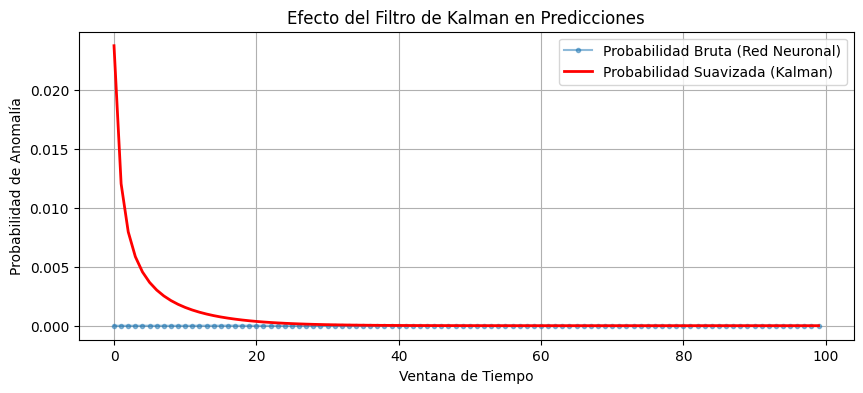

In [16]:
kf = KalmanSmoother(process_variance=1e-3, measurement_variance=0.05)
probabilidades_suavizadas = []

for p in test_probs[:100]:
    p_suavizada = kf.update(p)
    probabilidades_suavizadas.append(p_suavizada)

plt.figure(figsize=(10, 4))
plt.plot(test_probs[:100], label='Probabilidad Bruta (Red Neuronal)', alpha=0.5, marker='o', markersize=3)
plt.plot(probabilidades_suavizadas, label='Probabilidad Suavizada (Kalman)', color='red', linewidth=2)
plt.title('Efecto del Filtro de Kalman en Predicciones')
plt.xlabel('Ventana de Tiempo')
plt.ylabel('Probabilidad de Anomalía')
plt.legend()
plt.grid(True)
plt.show()